In [31]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.optimize import curve_fit
from itertools import combinations
import yaml
import pandas_datareader.data as web
import os
import re
import requests
import json
from datetime import datetime
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

## Autocorrelation Analysis of Bond Yields

The goal of this analysis is to find the autocorrelation patterns in bond yields over different time lags. We will use the daily yield data of various US Treasury bonds and analyze their autocorrelation functions (ACF) to identify significant lags that can be used for predictive modeling.

Use both partial and full autocorrelation functions to identify significant lags.

In [5]:
# load in the dataset
data_bonds = pd.read_parquet('./training_data_diff.parquet')
# keep only the bond yield columns
dependent_varaibles = [
    'DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30'
]

independent_variables = [col for col in data_bonds.columns if col not in dependent_varaibles]


In [6]:
data_bonds.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,spread_DGS5_lag_200_day_avg_vs_DGS7_lag_200_day_avg,spread_DGS5_lag_200_day_avg_vs_DGS10_lag_200_day_avg,spread_DGS5_lag_200_day_avg_vs_DGS20_lag_200_day_avg,spread_DGS5_lag_200_day_avg_vs_DGS30_lag_200_day_avg,spread_DGS7_lag_200_day_avg_vs_DGS10_lag_200_day_avg,spread_DGS7_lag_200_day_avg_vs_DGS20_lag_200_day_avg,spread_DGS7_lag_200_day_avg_vs_DGS30_lag_200_day_avg,spread_DGS10_lag_200_day_avg_vs_DGS20_lag_200_day_avg,spread_DGS10_lag_200_day_avg_vs_DGS30_lag_200_day_avg,spread_DGS20_lag_200_day_avg_vs_DGS30_lag_200_day_avg
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-03,0.04,0.03,0.0,0.00,0.00,0.01,0.01,0.03,0.06,0.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-04,0.01,-0.01,0.0,-0.01,0.02,0.01,-0.01,-0.02,0.00,0.03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-05,0.01,0.00,0.0,0.03,0.08,0.12,0.13,0.14,0.14,0.13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


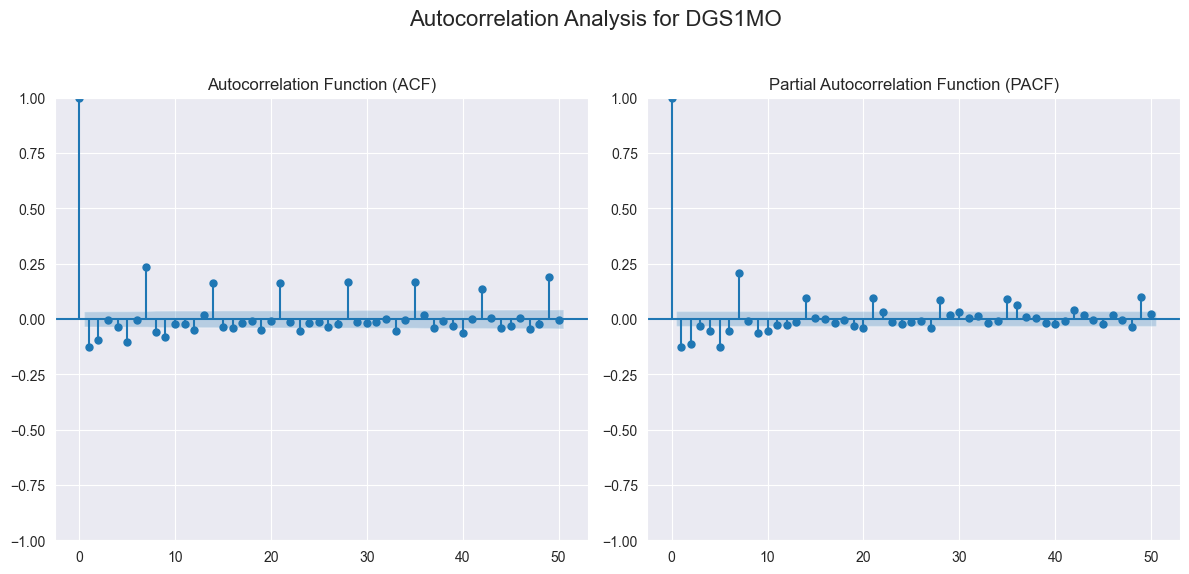

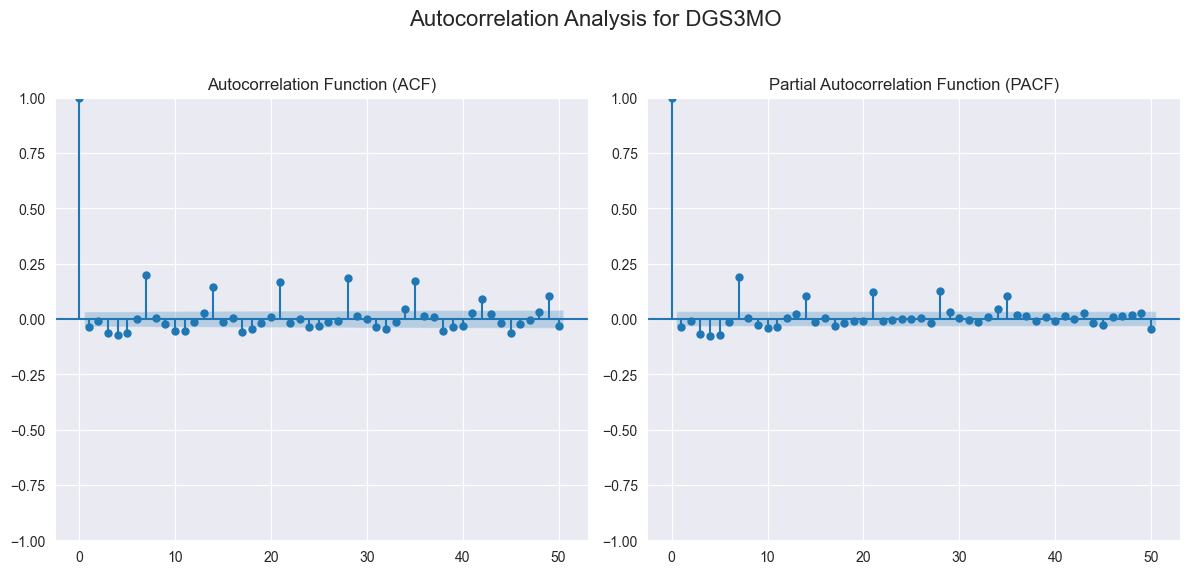

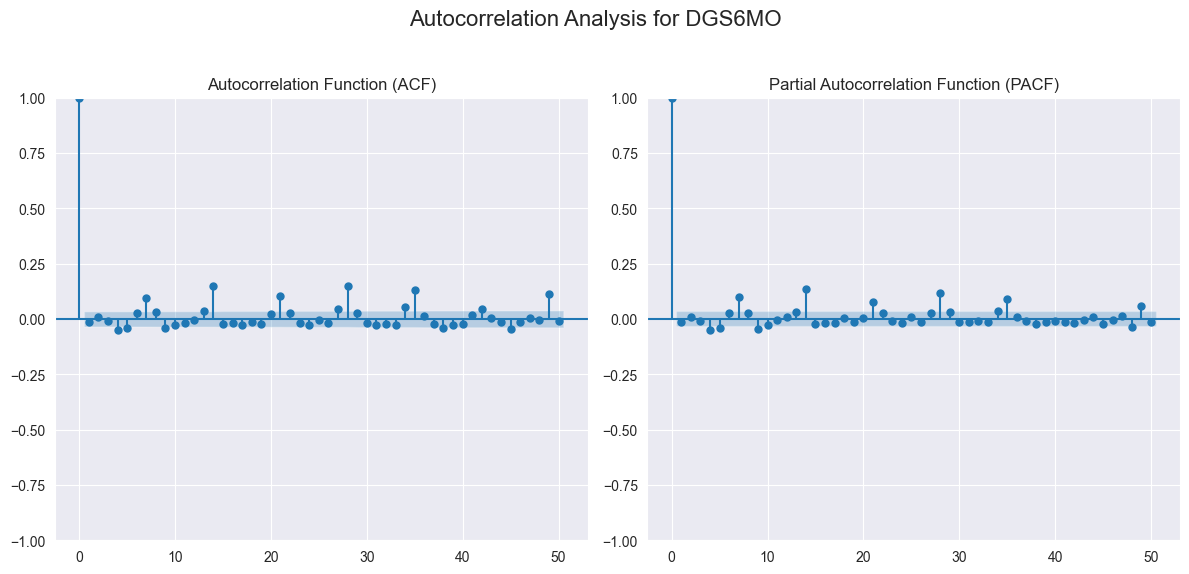

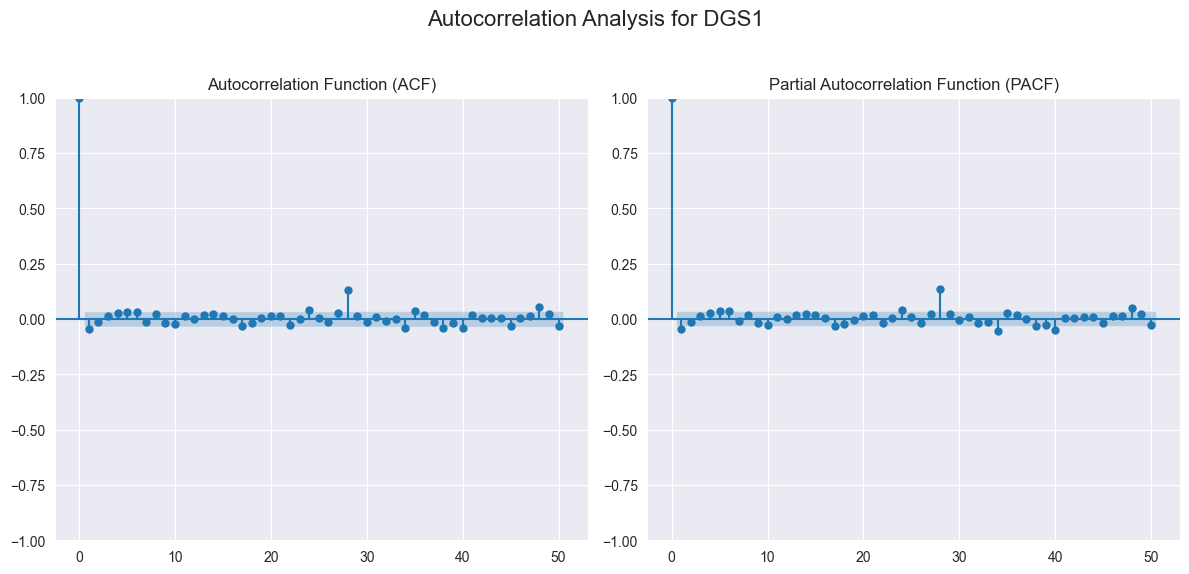

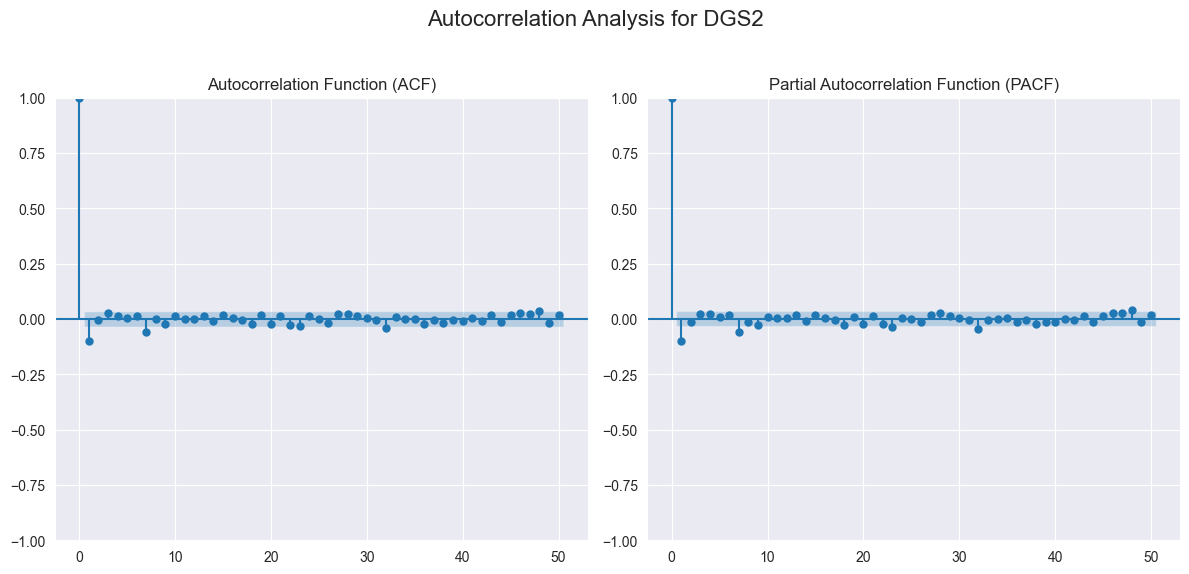

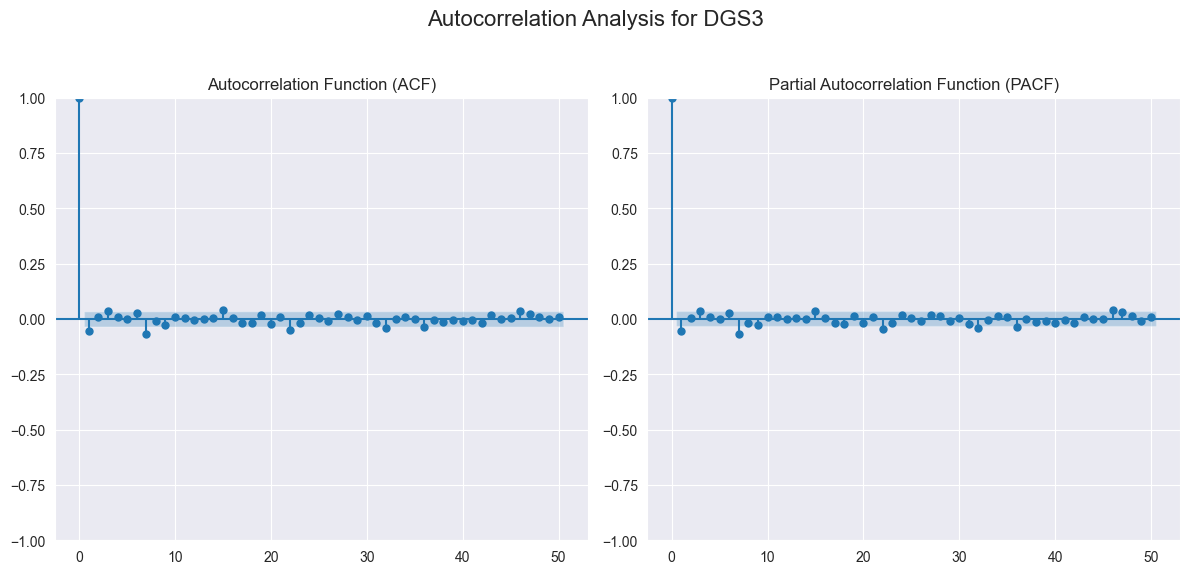

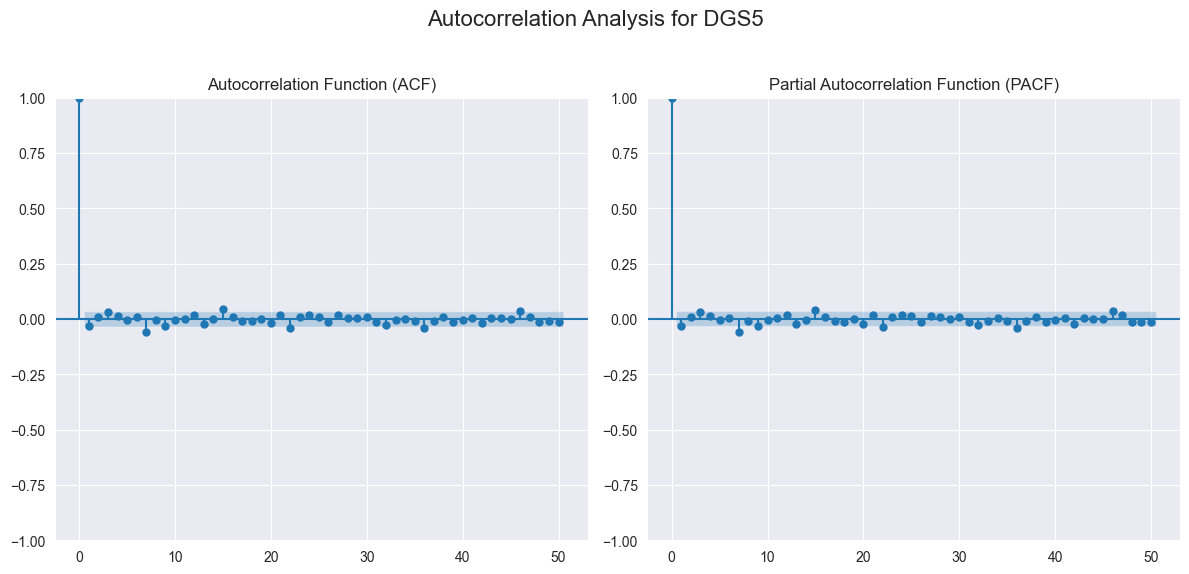

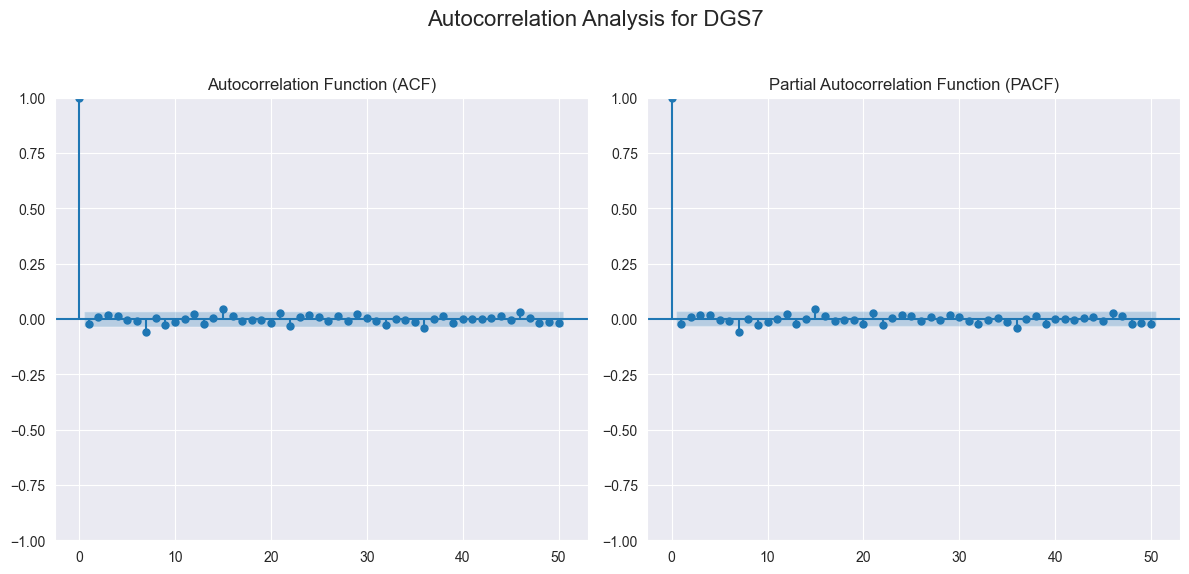

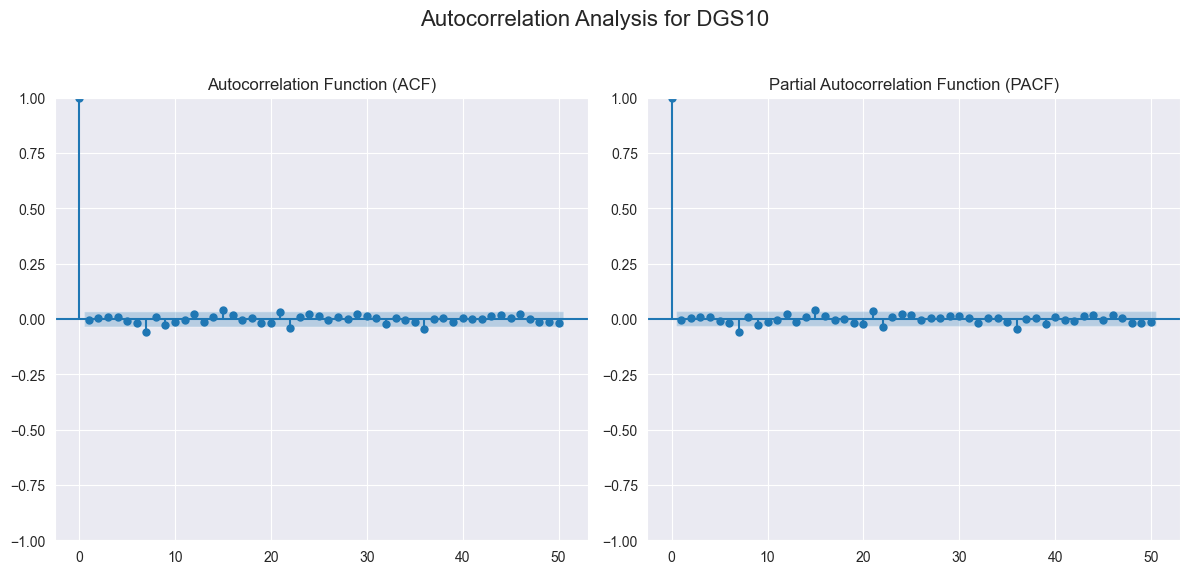

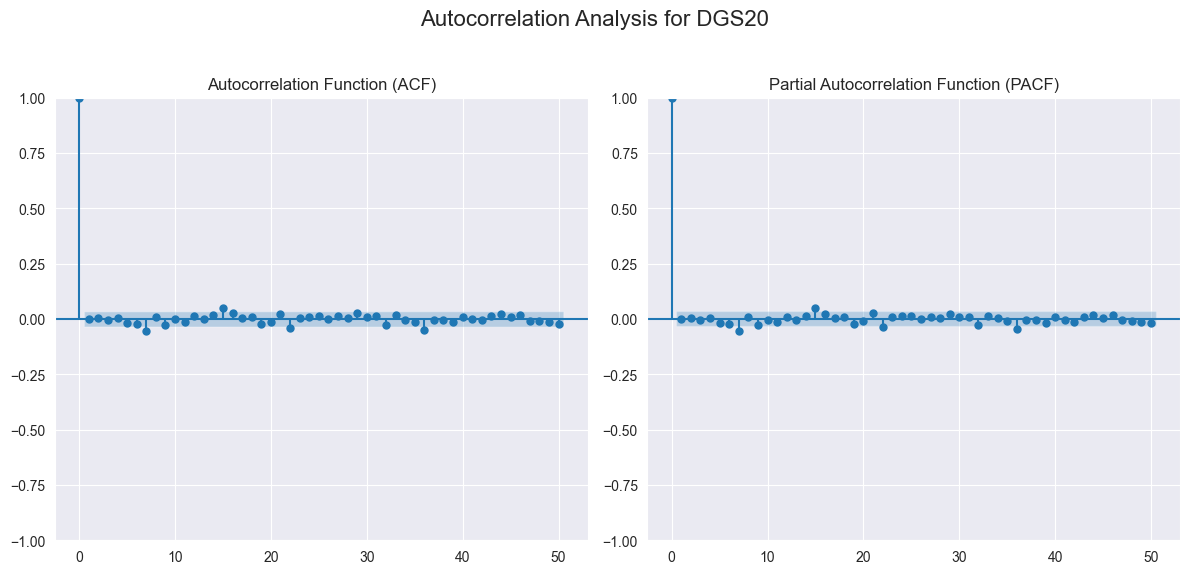

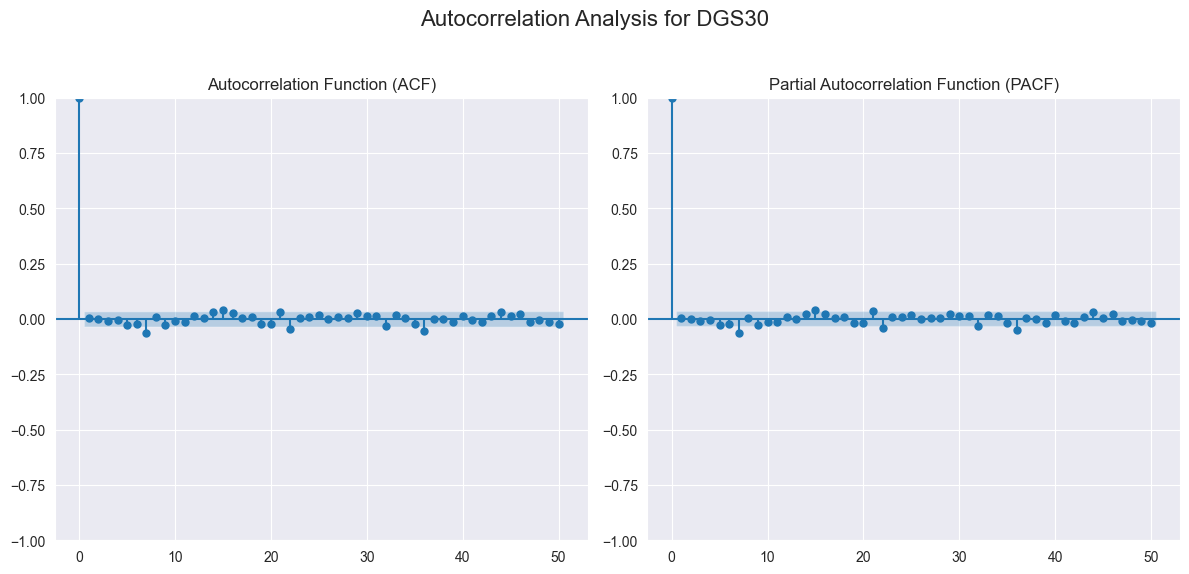

In [8]:
# get the autocorrelation function for each bond yield
for bond in dependent_varaibles:
    plt.figure(figsize=(12, 6))
    plt.suptitle(f'Autocorrelation Analysis for {bond}', fontsize=16)

    plt.subplot(1, 2, 1)
    plot_acf(data_bonds[bond].dropna(), lags=50, ax=plt.gca())
    plt.title('Autocorrelation Function (ACF)')

    plt.subplot(1, 2, 2)
    plot_pacf(data_bonds[bond].dropna(), lags=50, ax=plt.gca(), method='ywm')
    plt.title('Partial Autocorrelation Function (PACF)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [10]:
bond_yields = pd.read_parquet(''
                              'rorcessed_daily_shifted.parquet')
bond_yields = bond_yields[dependent_varaibles]
# get the index values from the data_bonds dataframe
bond_yields_train = bond_yields[bond_yields.index.to_timestamp() < pd.Timestamp('2020-01-01')]
bond_yields_test = bond_yields[bond_yields.index.to_timestamp() >= pd.Timestamp('2020-01-01')]

print("Training set time period:", bond_yields_train.index.min(), "to", bond_yields_train.index.max())
print("Testing set time period:", bond_yields_test.index.min(), "to", bond_yields_test.index.max())
print(bond_yields_train.shape)

Training set time period: 2011-01-01 to 2019-12-31
Testing set time period: 2020-01-01 to 2023-12-31
(3287, 11)


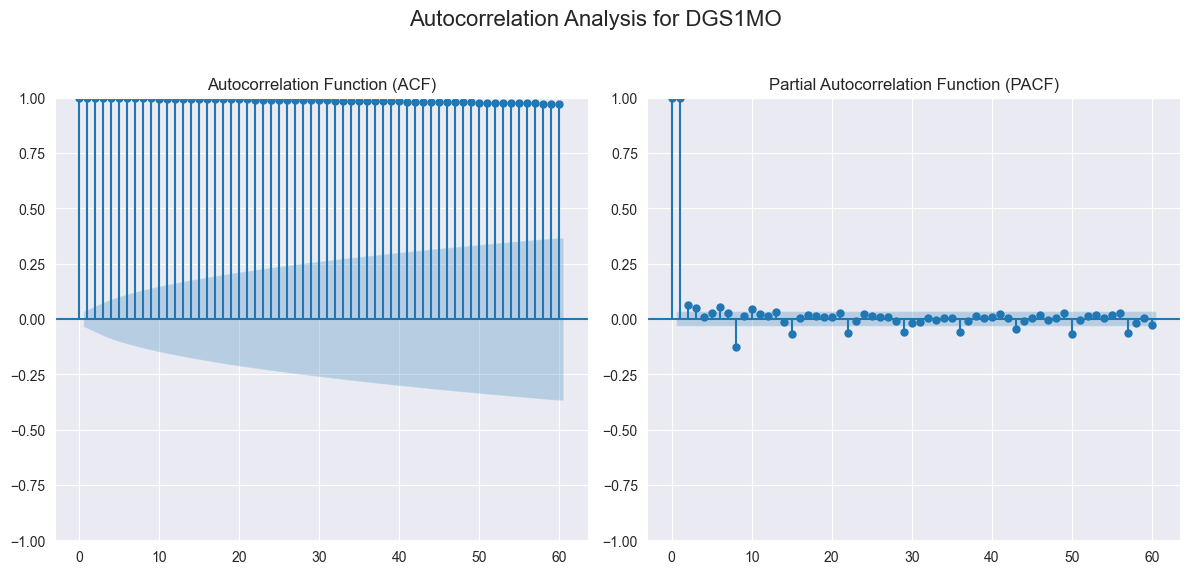

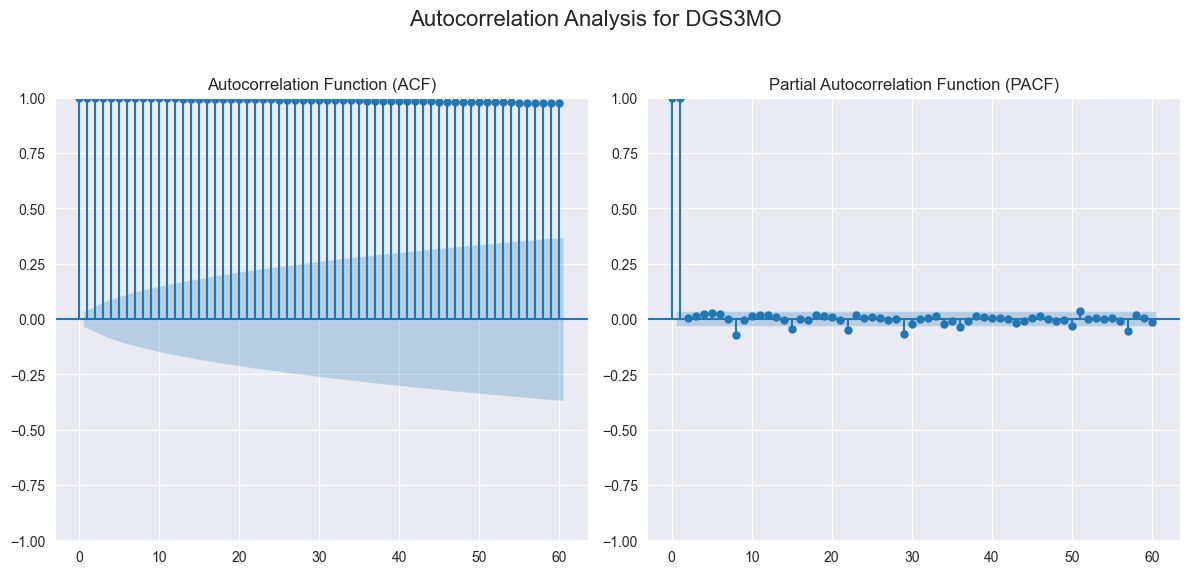

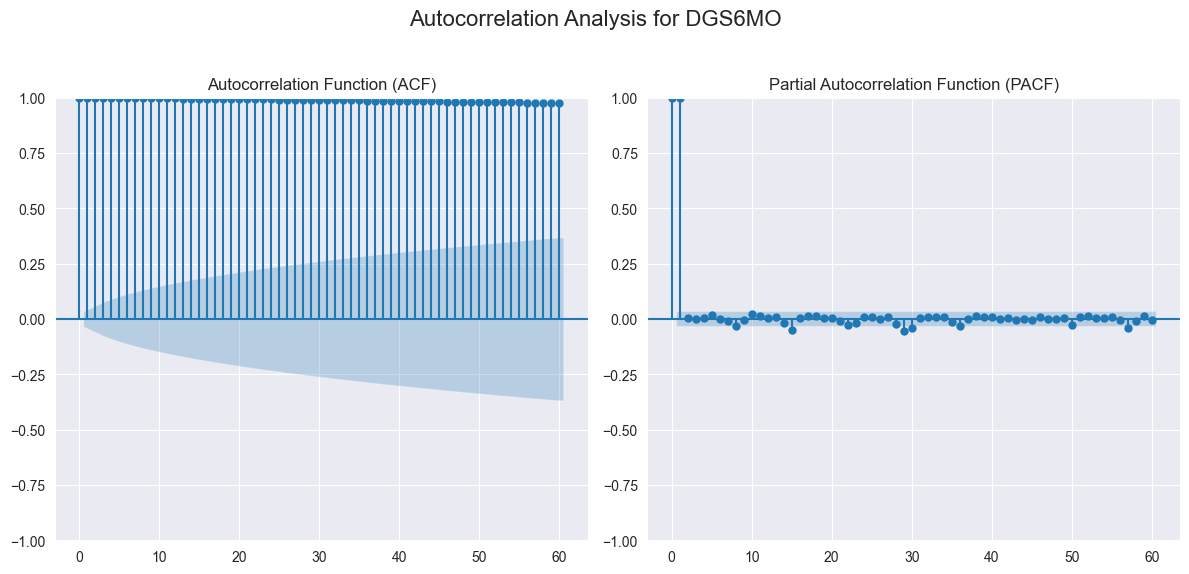

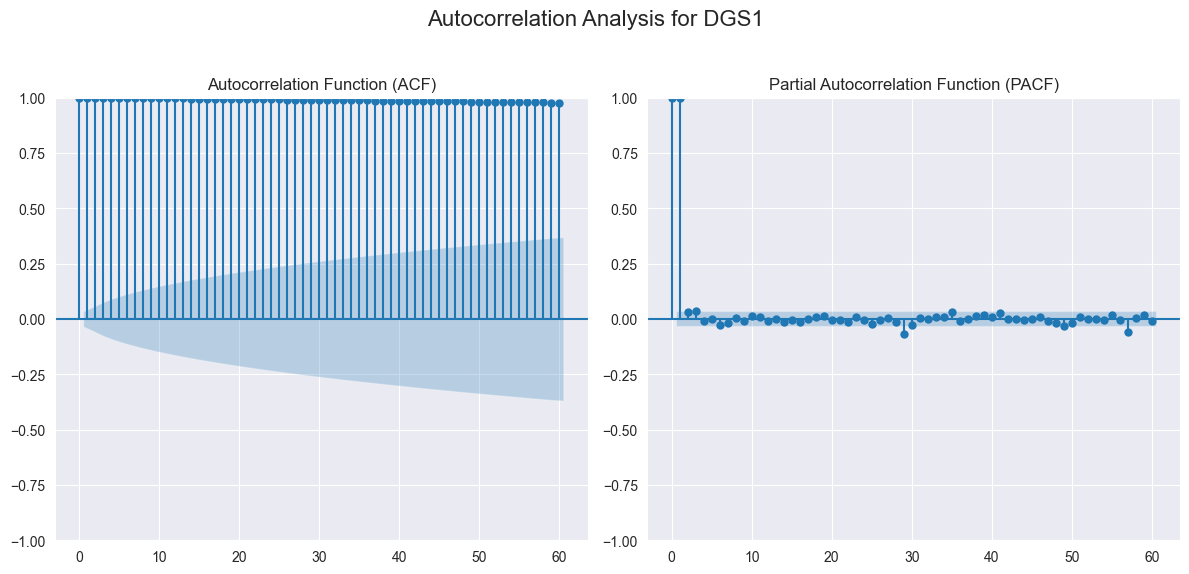

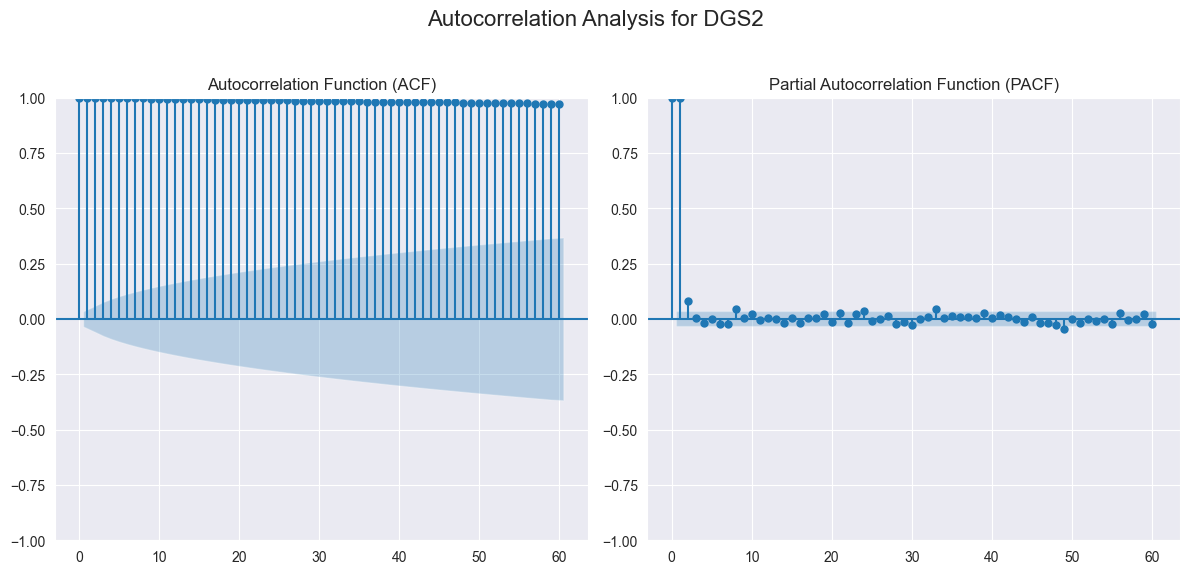

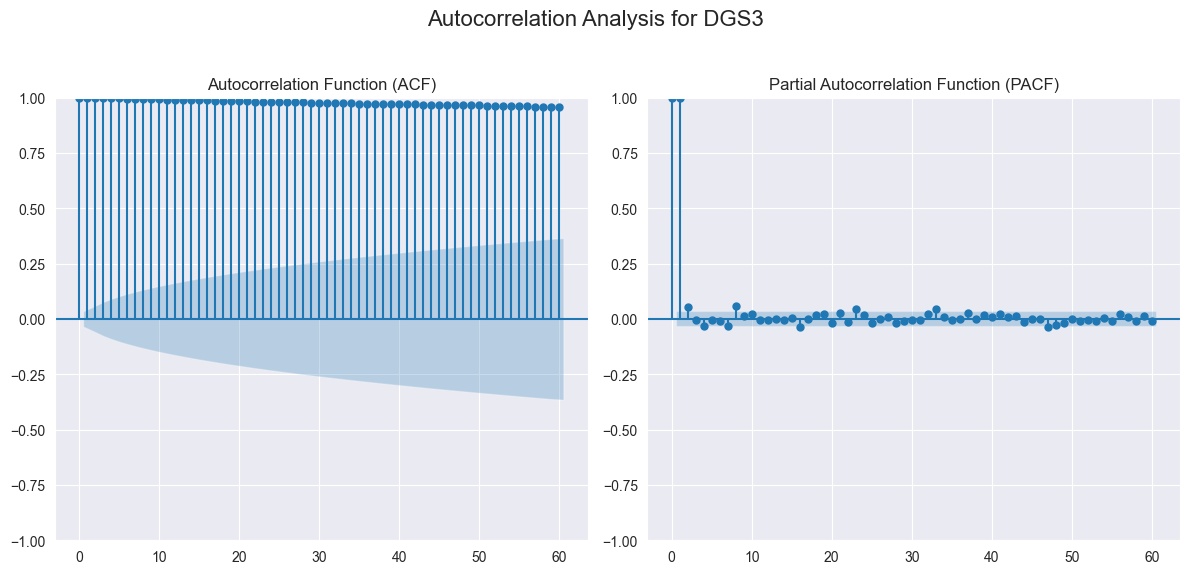

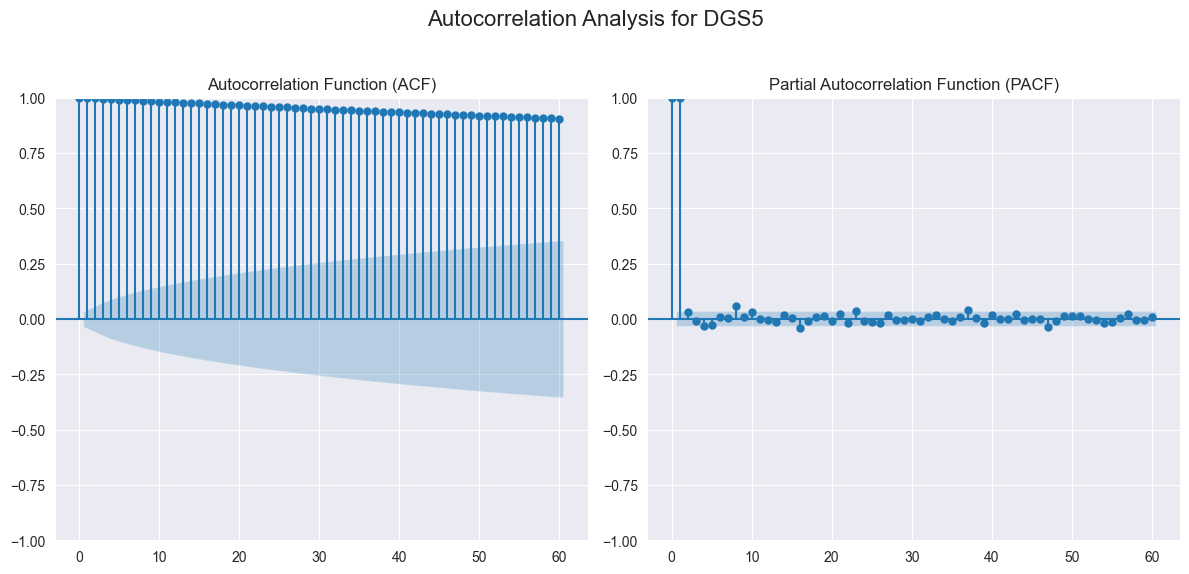

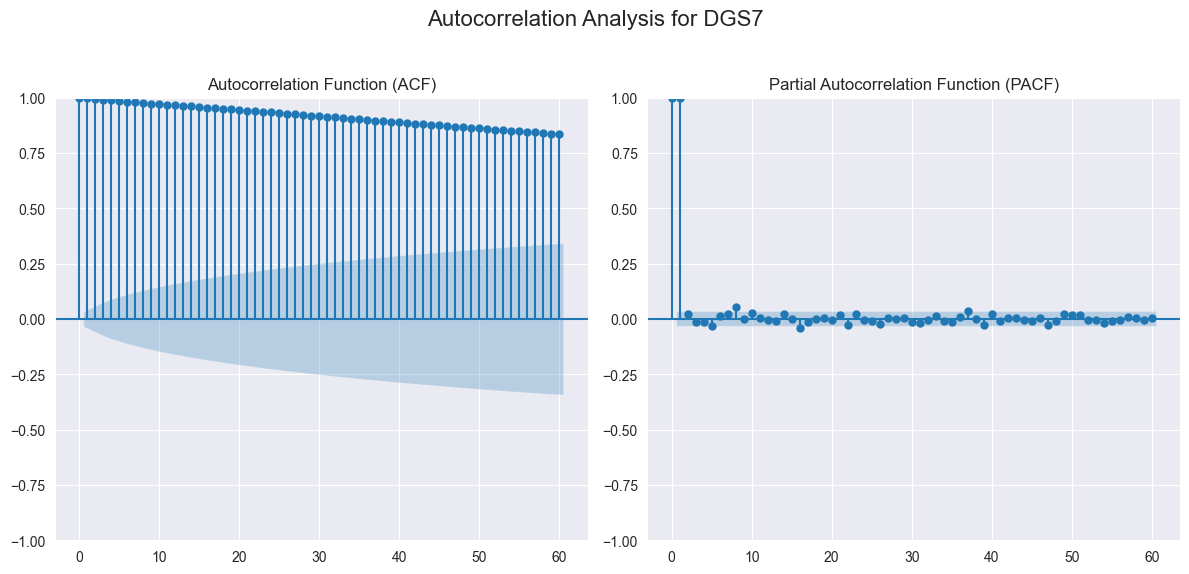

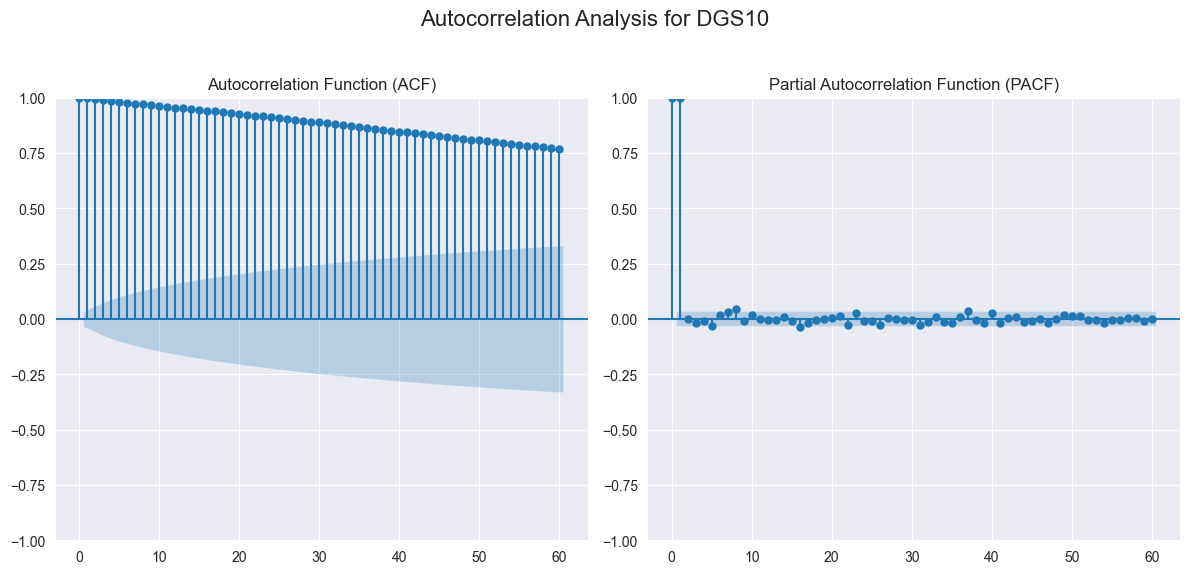

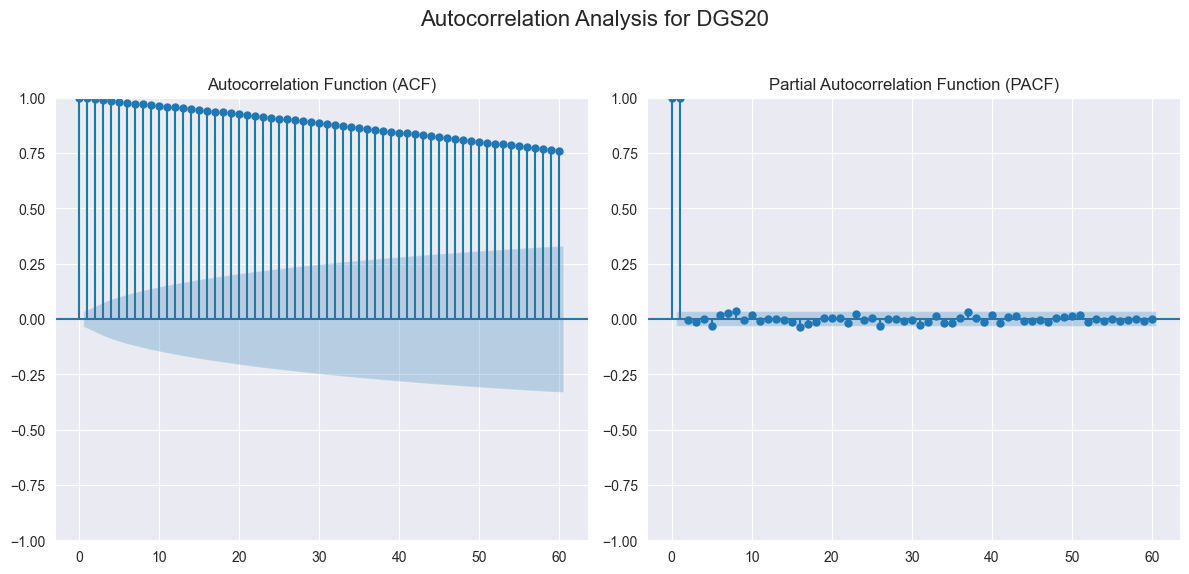

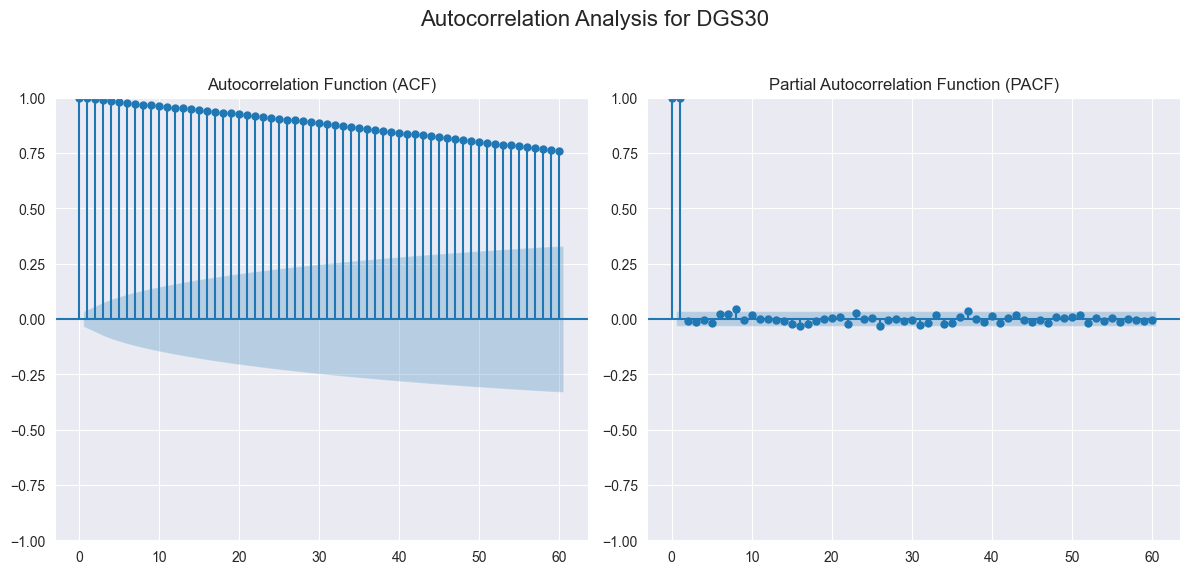

In [80]:
for bond in dependent_varaibles:
    plt.figure(figsize=(12, 6))
    plt.suptitle(f'Autocorrelation Analysis for {bond}', fontsize=16)

    plt.subplot(1, 2, 1)
    plot_acf(bond_yields_train[bond].dropna(), lags=60, ax=plt.gca())
    plt.title('Autocorrelation Function (ACF)')

    plt.subplot(1, 2, 2)
    plot_pacf(bond_yields_train[bond].dropna(), lags=60, ax=plt.gca(), method='ywm')
    plt.title('Partial Autocorrelation Function (PACF)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [11]:
bond_yields_train.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
period,,,,,,,,,,,
2011-01-01,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,4.34
2011-01-02,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,4.34
2011-01-03,0.11,0.15,0.19,0.29,0.61,1.03,2.02,2.74,3.36,4.18,4.39
2011-01-04,0.12,0.14,0.19,0.28,0.63,1.04,2.01,2.72,3.36,4.21,4.44
2011-01-05,0.13,0.14,0.19,0.31,0.71,1.16,2.14,2.86,3.50,4.34,4.55


In [29]:
# pick 5 random indexes from the training set
# random_indexes = np.random.choice(bond_yields_train.index, size=6, replace=False)
# random_indexes
random_indexes2 = ['2015-06-15', '2016-09-20', '2017-12-25', '2018-03-30', '2019-07-04', '2019-11-11']

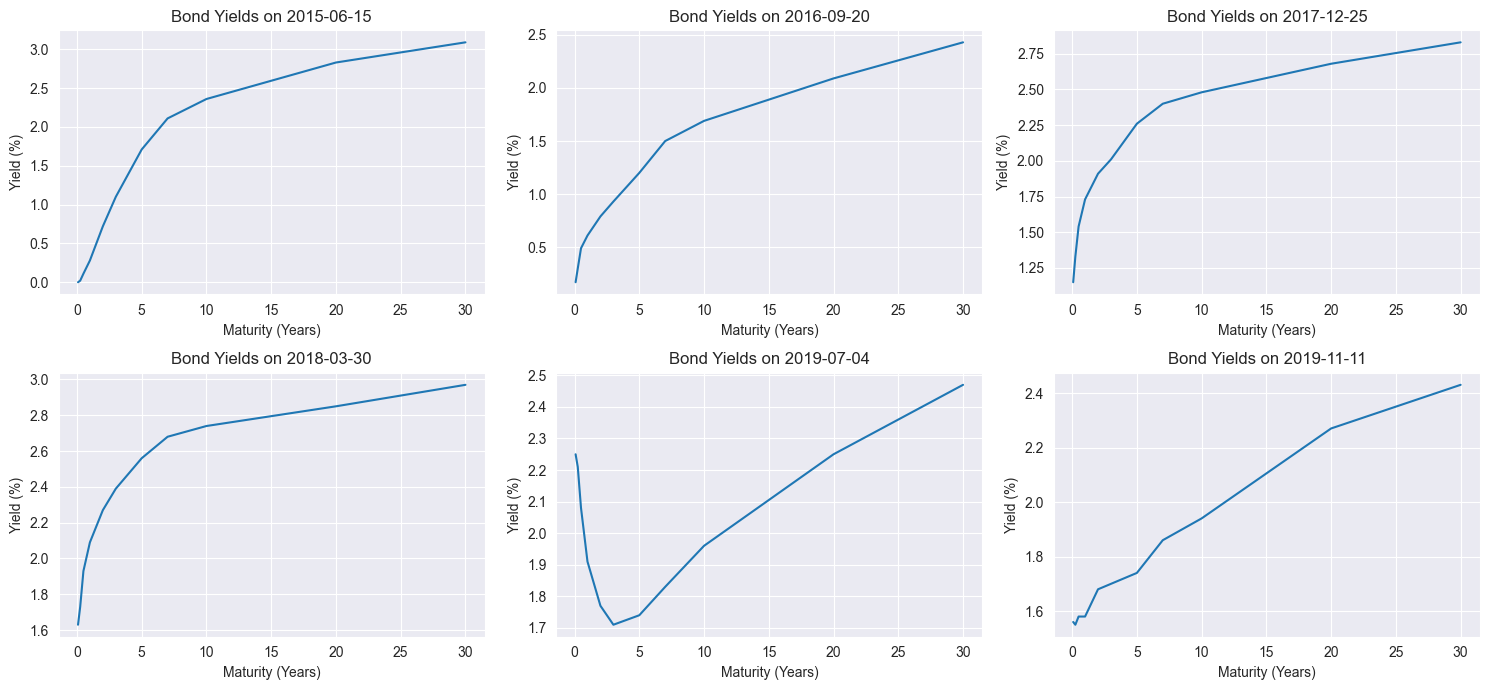

In [30]:
# plot the random indexes
x_labels = [round(1/12, 3), 1/4, 1/2, 1, 2, 3, 5, 7, 10, 20, 30]

# create a 3 by 3 subplot
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for i, idx in enumerate(random_indexes2):
    # create a line plot for each bond yield
    y_values = bond_yields_train.loc[idx].values
    sns.lineplot(x=x_labels, y=y_values, ax=axes[i])
    axes[i].set_title(f'Bond Yields on {idx}')
    axes[i].set_xlabel('Maturity (Years)')
    axes[i].set_ylabel('Yield (%)')

plt.tight_layout()
plt.show()

In [33]:
# Create features for the yield curves
def nelson_siegel(maturity, beta0, beta1, beta2, lambda_):
        return (beta0 +
                beta1 * ((1 - np.exp(-lambda_ * maturity)) / (lambda_ * maturity)) +
                beta2 * (((1 - np.exp(-lambda_ * maturity)) / (lambda_ * maturity)) - np.exp(-lambda_ * maturity)))


def nelson_siegel_params(yields, maturities):
    """
    Fit the Nelson-Siegel model to the yield curve data and return the parameters.
    Yields: array-like, bond yields
    Maturities: array-like, bond maturities in years
    """
    # Initial guess for the parameters
    initial_guess = [0.03, -0.02, 0.02, 0.5]
    # Fit the model
    params, _ = curve_fit(nelson_siegel, maturities, yields, p0=initial_guess)
    return params

In [37]:
maturieties = [round(1/12, 3), 1/4, 1/2, 1, 2, 3, 5, 7, 10, 20, 30]
yields = bond_yields_train.loc['2015-06-15'].values / 100
ns_params = nelson_siegel_params(yields, maturieties)

# make the predictions
predicted_yields = nelson_siegel(np.array(maturieties), *ns_params)

In [39]:
predicted_yields = predicted_yields * 100
yields = yields * 100
# plot the actual vs predicted yields
df_predicted = pd.DataFrame({
    'Maturity': maturieties,
    'Actual Yields': yields,
    'Predicted Yields': predicted_yields
})
df_predicted

,Maturity,Actual Yields,Predicted Yields
0,0.083,0.00,-0.017532
1,0.250,0.02,0.030168
2,0.500,0.11,0.112194
3,1.000,0.28,0.301040
4,2.000,0.72,0.710203
5,3.000,1.10,1.093386
6,5.000,1.71,1.689341
7,7.000,2.11,2.081122
8,10.000,2.36,2.432431
9,20.000,2.83,2.874446


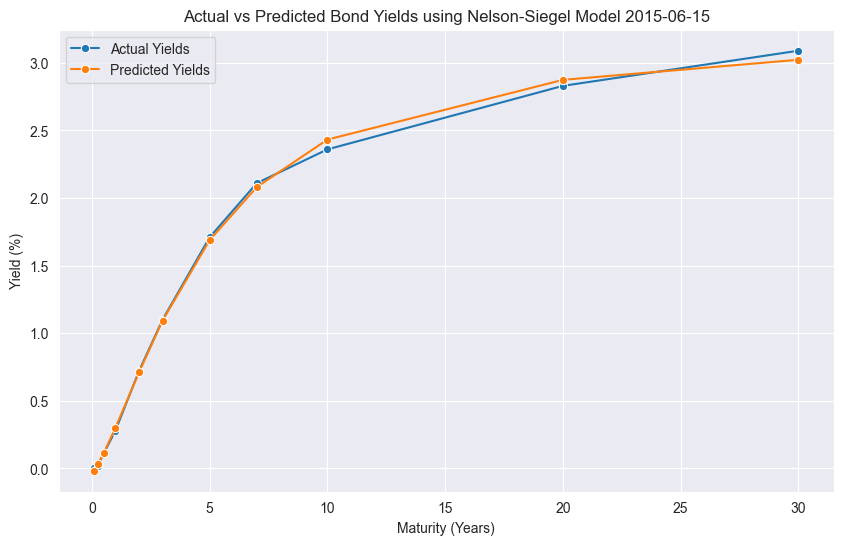

In [41]:
# melt the data for plotting
df_melted = df_predicted.melt(id_vars='Maturity', value_vars=['Actual Yields', 'Predicted Yields'], var_name='Type', value_name='Yield')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='Maturity', y='Yield', hue='Type', marker='o')
plt.title('Actual vs Predicted Bond Yields using Nelson-Siegel Model 2015-06-15')
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield (%)')
plt.legend()
plt.show()

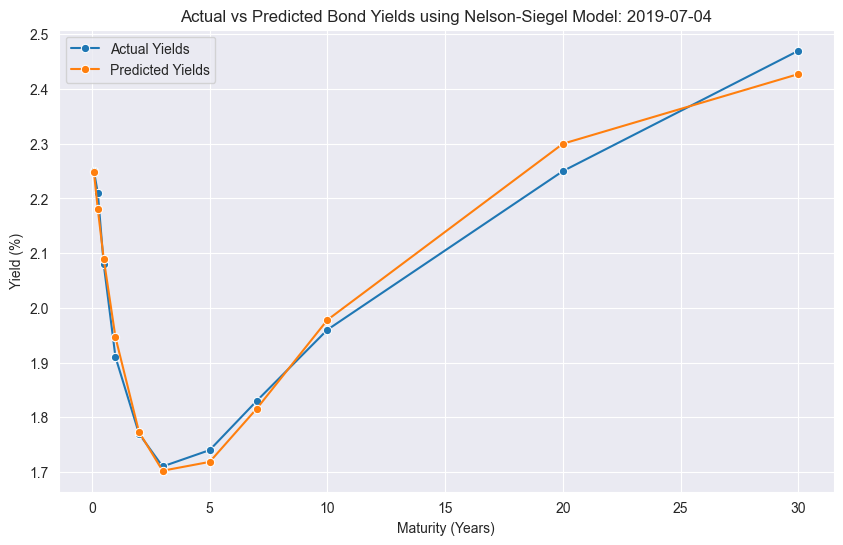

In [42]:
yields = bond_yields_train.loc['2019-07-04'].values / 100
ns_params = nelson_siegel_params(yields, maturieties)
# make the predictions
predicted_yields = nelson_siegel(np.array(maturieties), *ns_params)

predicted_yields = predicted_yields * 100
yields = yields * 100
# plot the actual vs predicted yields
df_predicted = pd.DataFrame({
    'Maturity': maturieties,
    'Actual Yields': yields,
    'Predicted Yields': predicted_yields
})

# melt the data for plotting
df_melted = df_predicted.melt(id_vars='Maturity', value_vars=['Actual Yields', 'Predicted Yields'], var_name='Type',
                              value_name='Yield')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='Maturity', y='Yield', hue='Type', marker='o')
plt.title('Actual vs Predicted Bond Yields using Nelson-Siegel Model: 2019-07-04')
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield (%)')
plt.legend()
plt.show()

In [44]:
# model the entire training set using the nelson_siegel_params function by applying it to each row
ns_param_columns = ['beta0', 'beta1', 'beta2', 'lambda']
bond_yields_ns_params = bond_yields_train.apply(lambda row: pd.Series(nelson_siegel_params(row.values / 100, maturieties), index=ns_param_columns), axis=1)
bond_yields_ns_params.head()

,beta0,beta1,beta2,lambda
period,,,,
2011-01-01,0.049463,-0.047990,-0.054737,0.611760
2011-01-02,0.049463,-0.047990,-0.054737,0.611760
2011-01-03,0.050050,-0.048164,-0.057179,0.622251
2011-01-04,0.050643,-0.048853,-0.056699,0.603432
2011-01-05,0.051663,-0.049933,-0.056482,0.622837


In [57]:
# create predictions using the nelson_siegel function for each row
bond_yields_ns_predictions = bond_yields_ns_params.apply(lambda row: nelson_siegel(np.array(maturieties), *row.values), axis=1)
bond_yields_ns_predictions = bond_yields_ns_predictions.apply(lambda x: x * 100)
bond_yields_ns_predictions = pd.DataFrame(bond_yields_ns_predictions.tolist(), index=bond_yields_ns_predictions.index, columns=[f'{maturity}' for maturity in dependent_varaibles])
# round each column to 2 decimal places
for col in bond_yields_ns_predictions.columns:
    bond_yields_ns_predictions[col] = bond_yields_ns_predictions[col].round(2)
bond_yields_ns_predictions.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
period,,,,,,,,,,,
2011-01-01,0.13,0.12,0.13,0.23,0.63,1.12,2.00,2.66,3.28,4.11,4.39
2011-01-02,0.13,0.12,0.13,0.23,0.63,1.12,2.00,2.66,3.28,4.11,4.39
2011-01-03,0.17,0.14,0.14,0.23,0.63,1.12,2.02,2.69,3.33,4.16,4.44
2011-01-04,0.16,0.14,0.15,0.24,0.63,1.12,2.01,2.69,3.33,4.19,4.48
2011-01-05,0.16,0.15,0.16,0.28,0.71,1.22,2.15,2.83,3.47,4.31,4.60


In [46]:
bond_yields_train.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
period,,,,,,,,,,,
2011-01-01,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,4.34
2011-01-02,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,4.34
2011-01-03,0.11,0.15,0.19,0.29,0.61,1.03,2.02,2.74,3.36,4.18,4.39
2011-01-04,0.12,0.14,0.19,0.28,0.63,1.04,2.01,2.72,3.36,4.21,4.44
2011-01-05,0.13,0.14,0.19,0.31,0.71,1.16,2.14,2.86,3.50,4.34,4.55


In [50]:
# perform point wise subtraction between bond_yields_train and bond_yields_ns_predictions
# bond_yields_residuals = bond_yields_train.to_numpy() - bond_yields_ns_predictions.to_numpy()
bond_yields_residuals = pd.DataFrame(bond_yields_residuals, index=bond_yields_train.index, columns=bond_yields_train.columns)
bond_yields_residuals.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
period,,,,,,,,,,,
2011-01-01,-0.06,0.00,0.06,0.06,-0.02,-0.10,0.01,0.05,0.02,0.02,-0.05
2011-01-02,-0.06,0.00,0.06,0.06,-0.02,-0.10,0.01,0.05,0.02,0.02,-0.05
2011-01-03,-0.06,0.01,0.05,0.06,-0.02,-0.09,0.00,0.05,0.03,0.02,-0.05
2011-01-04,-0.04,0.00,0.04,0.04,0.00,-0.08,0.00,0.03,0.03,0.02,-0.04
2011-01-05,-0.03,-0.01,0.03,0.03,0.00,-0.06,-0.01,0.03,0.03,0.03,-0.05


In [60]:
# create a date column for the residuals dataframe and the predictiosn dataframe
bond_yields_residuals['Date'] = bond_yields_residuals.index
bond_yields_ns_predictions['Date'] = bond_yields_ns_predictions.index
# melt the residuals dataframe and the predictions dataframe with the date column as id_vars
bond_yields_residuals_melted = bond_yields_residuals.melt(id_vars='Date', var_name='Maturity', value_name='Residual')
bond_yields_ns_predictions_melted = bond_yields_ns_predictions.melt(id_vars='Date', var_name='Maturity', value_name='Predicted_Yield')
# join the two dataframes on the date and maturity columns
bond_yields_combined = bond_yields_residuals_melted.merge(bond_yields_ns_predictions_melted, left_on=['Date', 'Maturity'], right_on=['Date', 'Maturity'], how='inner', suffixes=('', ''))
bond_yields_combined.head()

,Date,Maturity,Residual,Predicted_Yield
0,2011-01-01,DGS1MO,-0.06,0.13
1,2011-01-02,DGS1MO,-0.06,0.13
2,2011-01-03,DGS1MO,-0.06,0.17
3,2011-01-04,DGS1MO,-0.04,0.16
4,2011-01-05,DGS1MO,-0.03,0.16


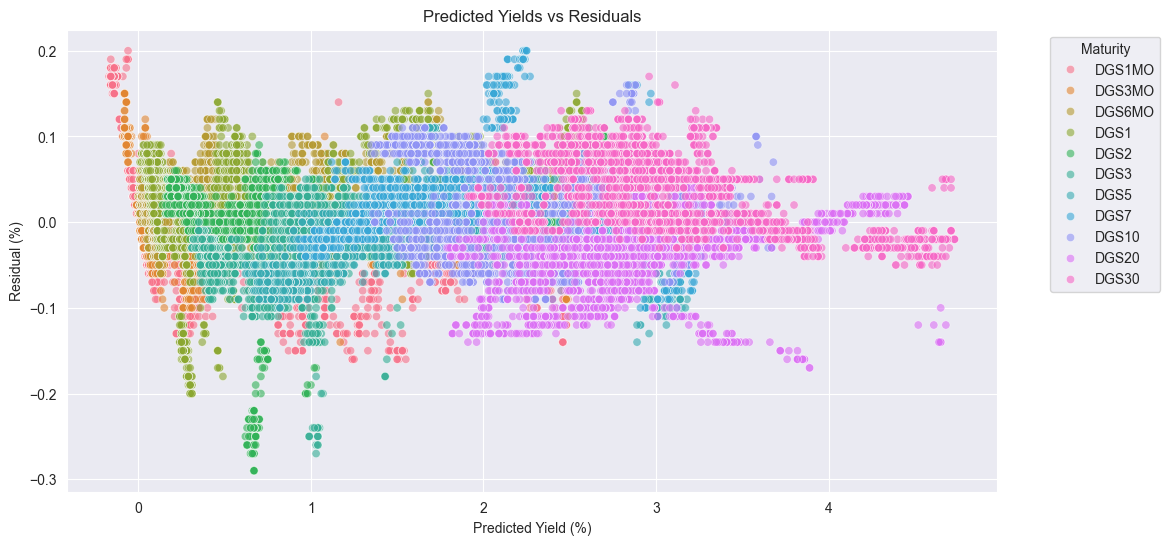

In [61]:
# plot the predicted yields vs the residuals
plt.figure(figsize=(12, 6))
sns.scatterplot(data=bond_yields_combined, x='Predicted_Yield', y='Residual', hue='Maturity', alpha=0.6)
plt.title('Predicted Yields vs Residuals')
plt.xlabel('Predicted Yield (%)')
plt.ylabel('Residual (%)')
plt.legend(title='Maturity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

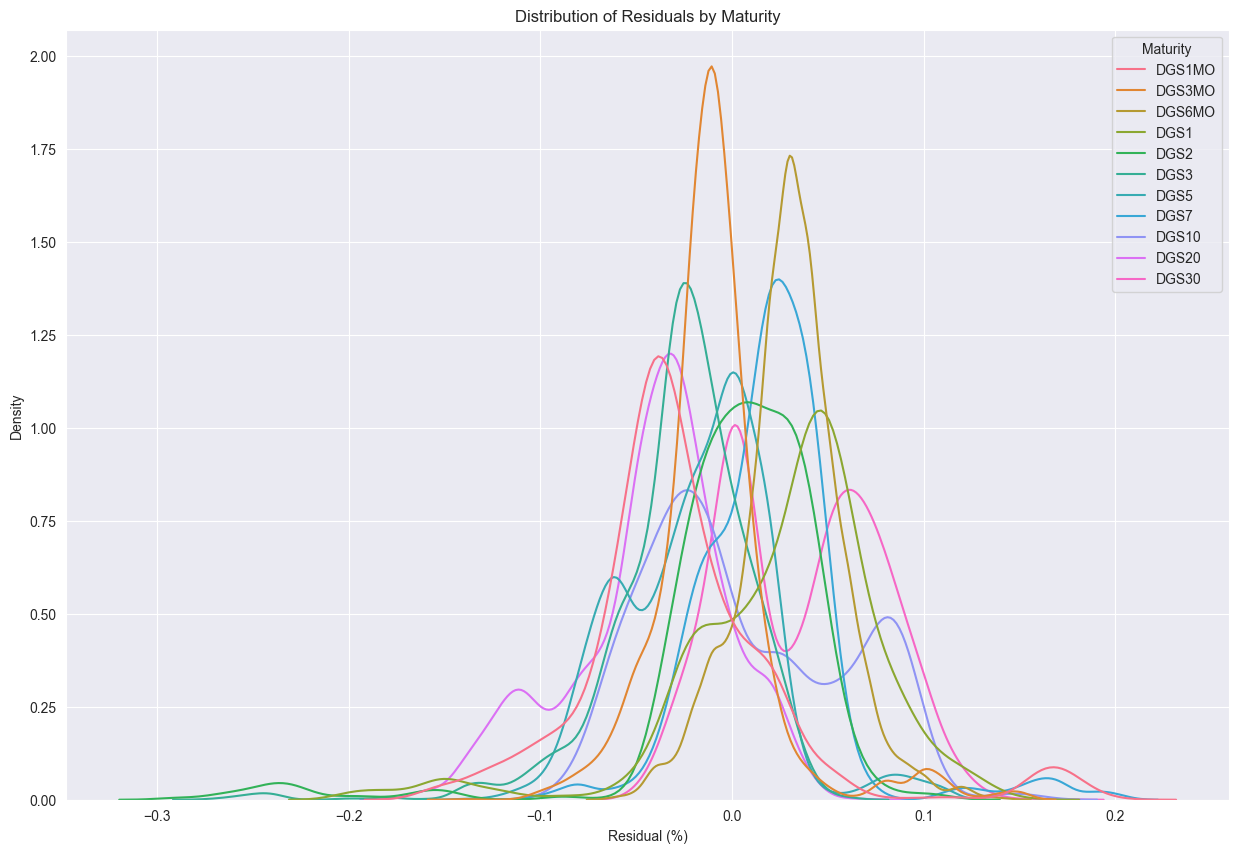

In [63]:
# plot the distribution of the residuals for each maturity
plt.figure(figsize=(15, 10))
sns.kdeplot(bond_yields_combined, x='Residual', hue='Maturity')
plt.title('Distribution of Residuals by Maturity')
plt.xlabel('Residual (%)')
plt.ylabel('Density')
# plt.legend(title='Maturity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [64]:
bond_yields_actuals = bond_yields_train.copy()
bond_yields_actuals['Date'] = bond_yields_actuals.index
# melt the residuals dataframe and the predictions dataframe with the date column as id_vars
bond_yields_actuals_melted = bond_yields_actuals.melt(id_vars='Date', var_name='Maturity', value_name='Actuals')
# join the two dataframes on the date and maturity columns
bond_yields_combined_actuals = bond_yields_actuals_melted.merge(bond_yields_ns_predictions_melted, left_on=['Date', 'Maturity'], right_on=['Date', 'Maturity'], how='inner', suffixes=('', ''))
bond_yields_combined_actuals.head()

,Date,Maturity,Actuals,Predicted_Yield
0,2011-01-01,DGS1MO,0.07,0.13
1,2011-01-02,DGS1MO,0.07,0.13
2,2011-01-03,DGS1MO,0.11,0.17
3,2011-01-04,DGS1MO,0.12,0.16
4,2011-01-05,DGS1MO,0.13,0.16


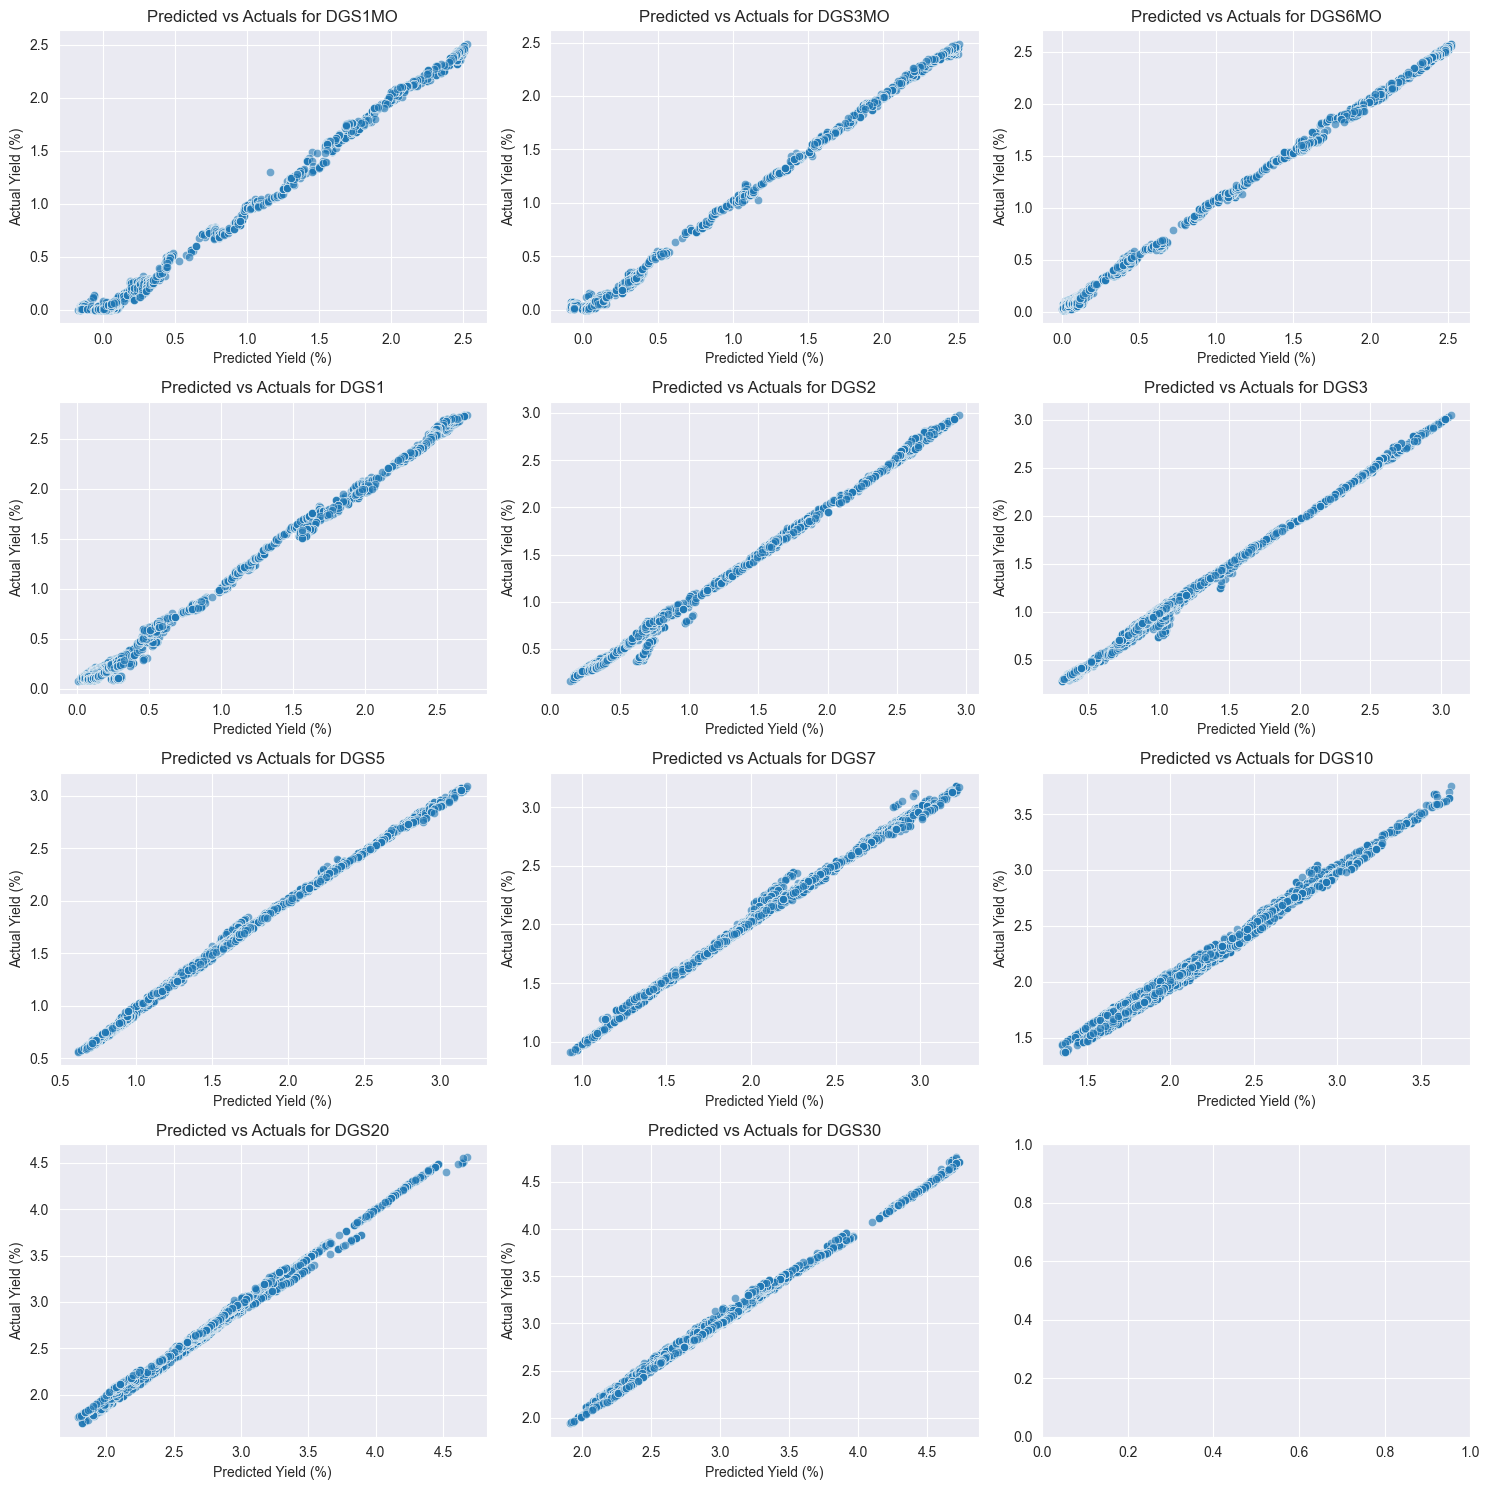

In [67]:
# create a scatter plot for each maturity using a subplot
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()
for i, maturity in enumerate(dependent_varaibles):
    sns.scatterplot(data=bond_yields_combined_actuals[bond_yields_combined_actuals['Maturity'] == maturity], x='Predicted_Yield', y='Actuals', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Predicted vs Actuals for {maturity}')
    axes[i].set_xlabel('Predicted Yield (%)')
    axes[i].set_ylabel('Actual Yield (%)')
plt.tight_layout()
plt.show()

## Vector Autoregression (VAR) Model and Analysis

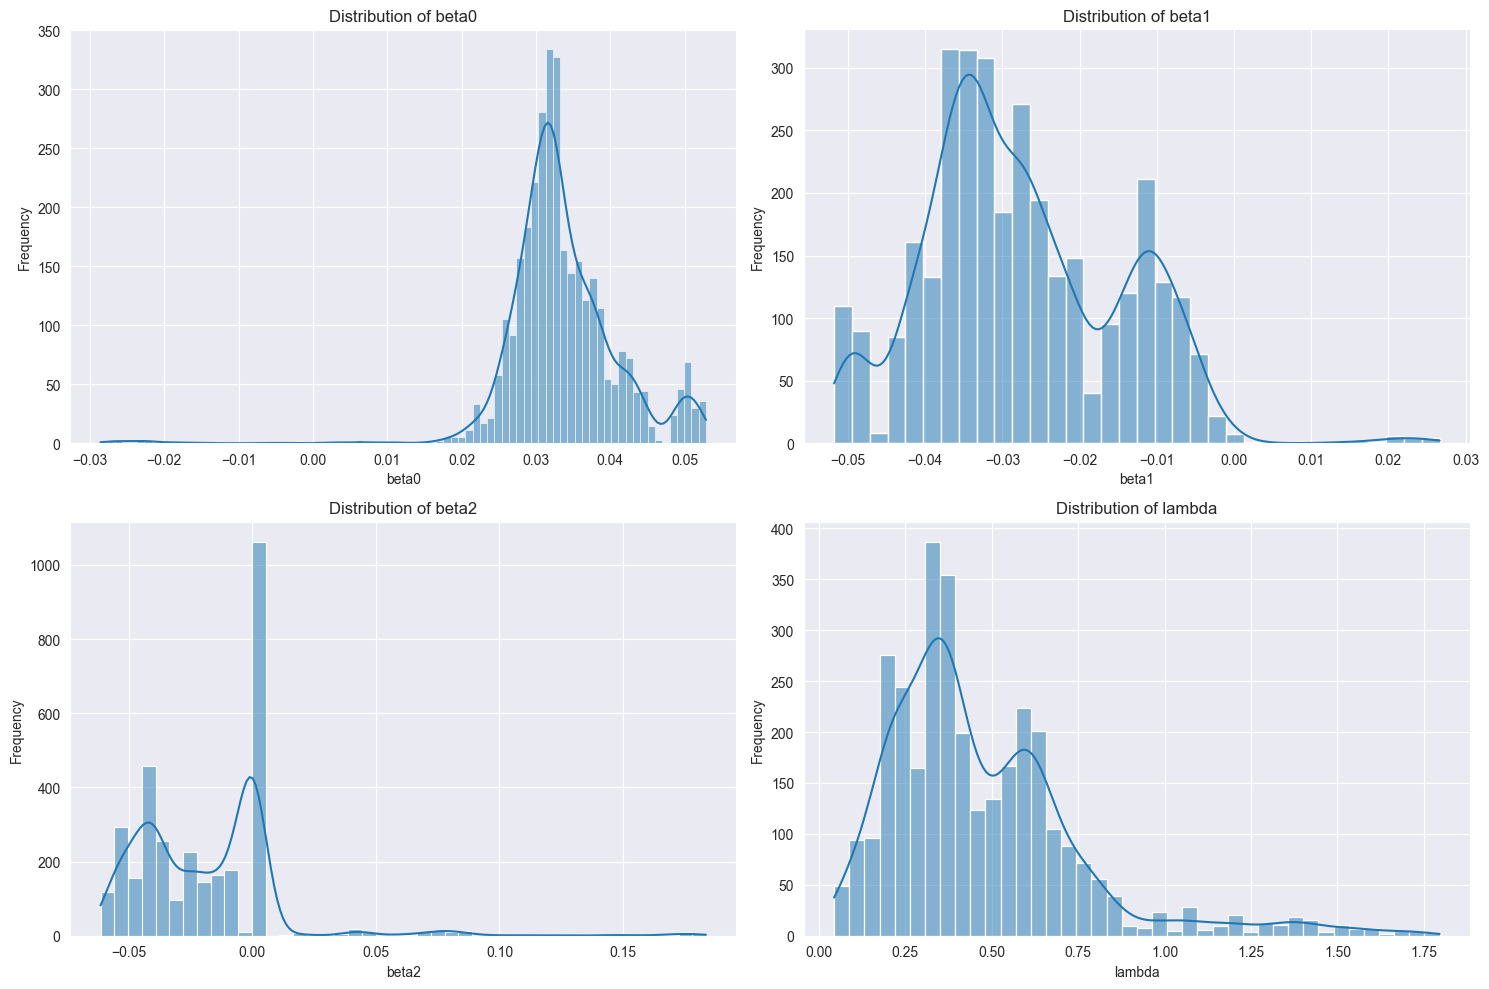

In [68]:
# plot the distributions of the nelson_siegel parameters
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, param in enumerate(ns_param_columns):
    sns.histplot(bond_yields_ns_params[param], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {param}')
    axes[i].set_xlabel(param)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()

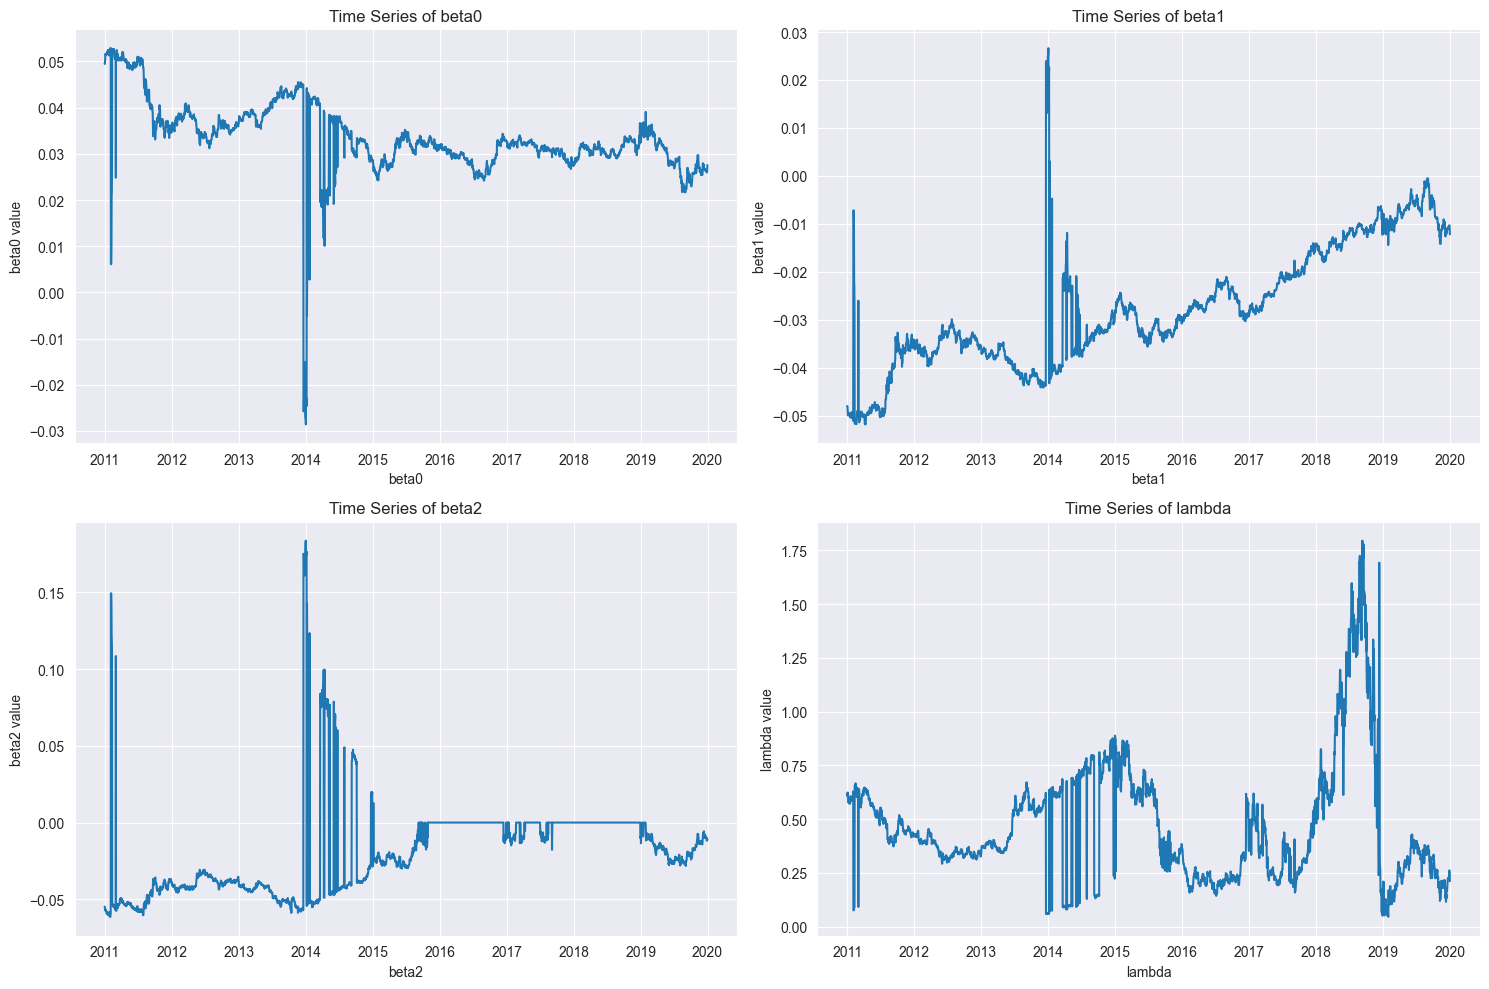

In [78]:
# bond_yields_ns_params['Date'] = bond_yields_ns_params.index.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, param in enumerate(ns_param_columns):
    sns.lineplot(bond_yields_ns_params, x='Date', y=param, ax=axes[i])
    axes[i].set_title(f'Time Series of {param}')
    axes[i].set_xlabel(param)
    axes[i].set_ylabel(f'{param} value')
plt.tight_layout()
plt.show()

In [90]:
# get the difference of the nelson_siegel parameters between time t + 60 and t
# bond_yields_ns_params[['beta0_diff_60', 'beta1_diff_60', 'beta2_diff_60', 'lambda_diff_60']] = bond_yields_ns_params[['beta0', 'beta1', 'beta2', 'lambda']].shift(-60) - bond_yields_ns_params[['beta0', 'beta1', 'beta2', 'lambda']]
bond_yields_ns_params.head()

,beta0,beta1,beta2,lambda,Date,beta0_diff_60,beta1_diff_60,beta2_diff_60,lambda_diff_60
period,,,,,,,,,
2011-01-01,0.049463,-0.047990,-0.054737,0.611760,2011-01-01,0.001686,-0.001532,-0.002327,0.029601
2011-01-02,0.049463,-0.047990,-0.054737,0.611760,2011-01-02,-0.024647,0.021962,0.163157,-0.520615
2011-01-03,0.050050,-0.048164,-0.057179,0.622251,2011-01-03,0.001731,-0.002123,-0.000203,0.013197
2011-01-04,0.050643,-0.048853,-0.056699,0.603432,2011-01-04,0.001138,-0.001434,-0.000684,0.032015
2011-01-05,0.051663,-0.049933,-0.056482,0.622837,2011-01-05,0.000118,-0.000354,-0.000901,0.012610


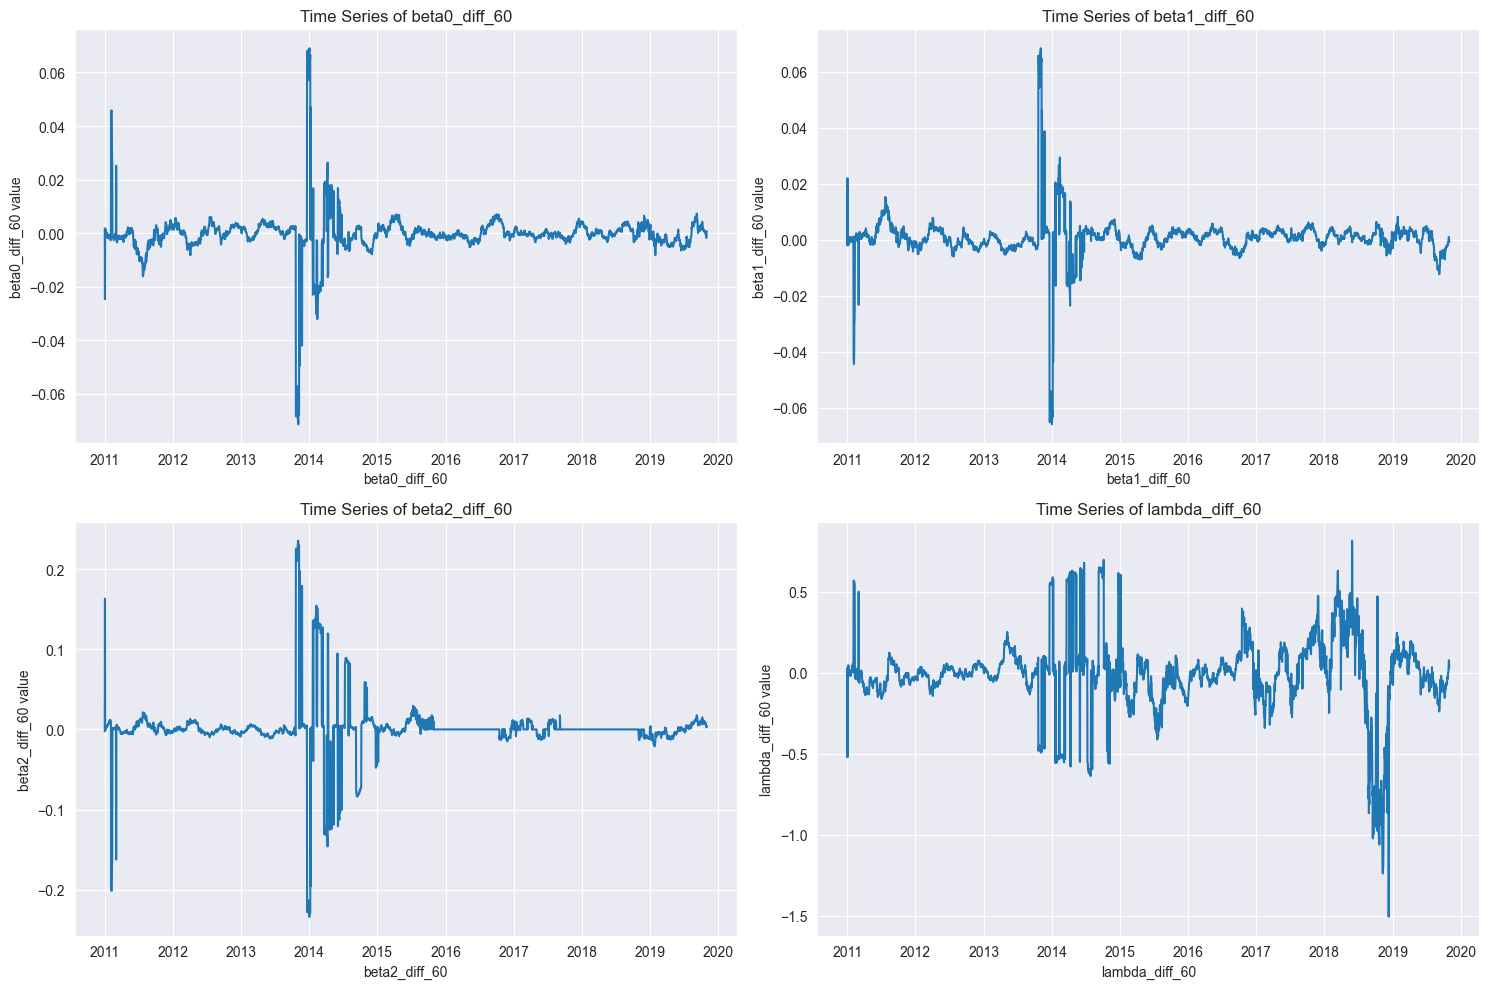

In [91]:
bond_yields_ns_params_diff = bond_yields_ns_params[['Date', 'beta0_diff_60', 'beta1_diff_60', 'beta2_diff_60', 'lambda_diff_60']].dropna()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, param in enumerate(['beta0_diff_60', 'beta1_diff_60', 'beta2_diff_60', 'lambda_diff_60']):
    sns.lineplot(bond_yields_ns_params_diff, x='Date', y=param, ax=axes[i])
    axes[i].set_title(f'Time Series of {param}')
    axes[i].set_xlabel(param)
    axes[i].set_ylabel(f'{param} value')
plt.tight_layout()
plt.show()

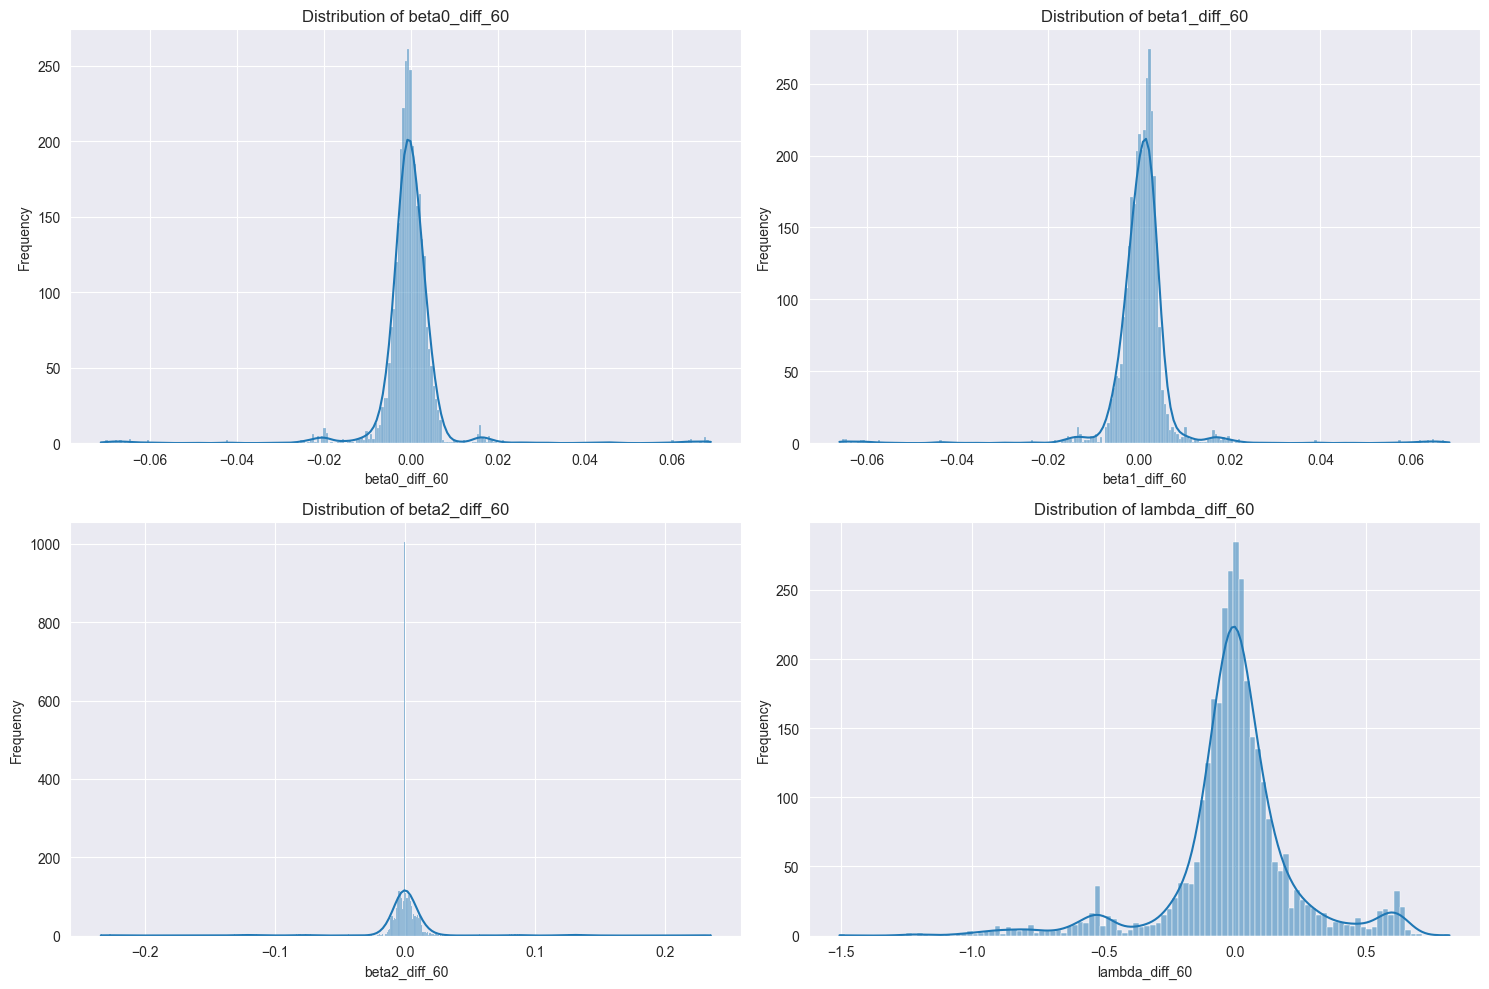

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, param in enumerate(['beta0_diff_60', 'beta1_diff_60', 'beta2_diff_60', 'lambda_diff_60']):
    sns.histplot(bond_yields_ns_params_diff[param], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {param}')
    axes[i].set_xlabel(param)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()

In [101]:
# load the fred macro data
df_macro = pd.read_parquet('./training_data_diff.parquet')
lag_cols = [col for col in independent_variables if "_lag_" in col or "_ma_spread" in col]
independent_variables = list(set(independent_variables) - set(lag_cols))
df_macro = df_macro[independent_variables]
df_macro['Date'] = df_macro.index.to_timestamp()
df_macro.head()

,PERMIT,GFDGDPA188S,GDPPOT,GDI,ADPWNUSNERSA,A939RX0Q048SBEA,MEPAINUSA672N,DEXUSUK,DGS7_lag,PCU332618332618,...,CREACBW027SBOG,STLFSI4,DAAA,A191RL1Q225SBEA,EFFR,BAMLH0A1HYBBEY,WPUID51,WPU3911,GASREGW,Date
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-01-01
2011-01-02,-0.056,0.047454,0.006796,0.009524,0.00062,-0.0228,-0.053,0.0000,NaN,0.009,...,0.0,0.0,0.00,-3.0,0.00,0.00,0.024,0.173,0.000,2011-01-02
2011-01-03,0.000,0.000000,0.000000,0.000000,0.00000,0.0000,0.000,0.0000,0.00,0.000,...,0.0,0.0,0.00,0.0,0.00,0.00,0.000,0.000,0.000,2011-01-03
2011-01-04,0.000,0.000000,0.000000,0.000000,0.00000,0.0000,0.000,0.0098,0.03,0.000,...,0.0,0.0,0.05,0.0,0.06,-0.05,0.000,0.000,0.018,2011-01-04
2011-01-05,0.000,0.000000,0.000000,0.000000,0.00000,0.0000,0.000,0.0096,-0.02,0.000,...,0.0,0.0,0.04,0.0,-0.01,-0.03,0.000,0.000,0.000,2011-01-05


In [ ]:
# merge the macro data with the 60 day diff nelson_siegel parameters on the date column

df_var = bond_yields_ns_params_diff.merge(df_macro, left_on='Date', right_index=True, how='inner')
df_var.set_index('Date', inplace=True)